# Parte 2: Reasoning y Function Calling

**Objetivo:** Explorar las capacidades avanzadas de Reasoning para resolver problemas lógicos mediante el ajuste de la profundidad del análisis, y aplicar Function Calling para permitir que el modelo interactúe con funciones personalizadas, superando así las limitaciones de su conocimiento estático.

*Reasoning* es la capacidad del modelo para "pensar" antes de responder mediante una cadena de lógica interna para resolver problemas complejos.

*Function Calling* es la habilidad de la IA para identificar y solicitar el uso de herramientas externas o código propio para obtener datos en tiempo real o realizar acciones que están fuera de su base de conocimientos estática.

### Configuración de entorno y modelos

In [1]:
%pip install openai python-dotenv azure-identity

Defaulting to user installation because normal site-packages is not writeable
  Using cached openai-2.31.0-py3-none-any.whl.metadata (31 kB)
  Using cached azure_identity-1.25.3-py3-none-any.whl.metadata (91 kB)
  Using cached azure_core-1.39.0-py3-none-any.whl.metadata (48 kB)
  Using cached cryptography-46.0.7-cp311-abi3-win_amd64.whl.metadata (5.7 kB)
  Using cached msal_extensions-1.3.1-py3-none-any.whl.metadata (7.8 kB)
  Using cached pyjwt-2.12.1-py3-none-any.whl.metadata (4.1 kB)
Using cached openai-2.31.0-py3-none-any.whl (1.2 MB)
Using cached azure_identity-1.25.3-py3-none-any.whl (192 kB)
Using cached azure_core-1.39.0-py3-none-any.whl (218 kB)
Using cached cryptography-46.0.7-cp311-abi3-win_amd64.whl (3.5 MB)
Using cached pyjwt-2.12.1-py3-none-any.whl (29 kB)
Using cached msal_extensions-1.3.1-py3-none-any.whl (20 kB)

   ----------------------------------------  0/11 [tqdm]
   ----------------------------------------  0/11 [tqdm]
   --- ------------------------------------ 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Modelo que vamos a utilizar:

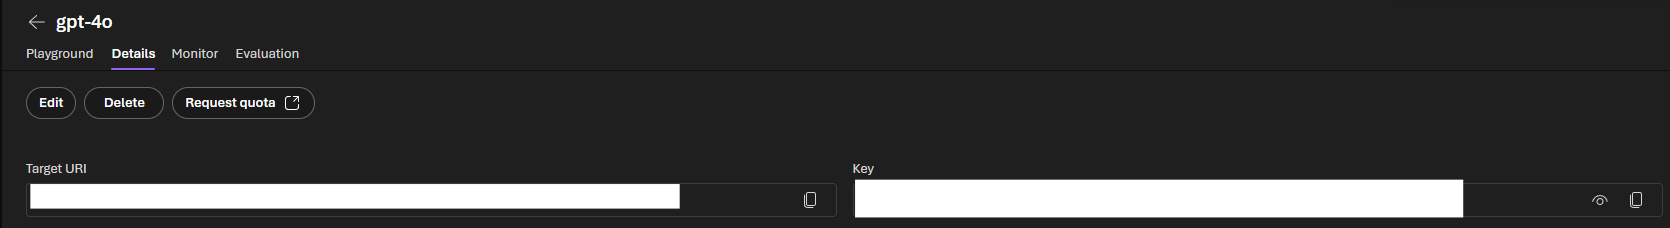

In [3]:
import os
import json
from openai import AzureOpenAI
from dotenv import load_dotenv

# 1. Carga de configuración
load_dotenv()

client = AzureOpenAI(
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),  
    api_version="2024-12-01-preview",
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT")
)

deployment_standard = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME")
deployment_reasoning = os.getenv("AZURE_OPENAI_REASONING_DEPLOYMENT_NAME")

## 2.1 Razonamiento (Reasoning)
Probamos el modelo razonador utilizando niveles de esfuerzo.

### GPT 4o 
Aplicando un modelo que **NO** razona. 

In [13]:
def probar_razonamiento_gpt4o(nivel):

    print(f"Razonamiento con nivel de esfuerzo: {nivel.upper()} ---")

    pregunta_logica = "Si 3 camisas tardan 3 horas en secarse al sol, ¿cuánto tardarán 9 camisas en secarse bajo las mismas condiciones?"

    print(f"\nTu preguntaste:{pregunta_logica}\n")

    prompt = {
        "low": "Responde de forma directa, mínima y sin ninguna explicación. Solo la respuesta final.",
        "medium": "Responde de forma lógica, explicando brevemente los pasos realizados.",
        "high": "Actúa como un motor de razonamiento avanzado. Antes de responder, analiza todas las variables, desglosa el problema paso a paso y justifica tu conclusión detalladamente."
    }
    
    
    try:
        response = client.chat.completions.create(
            model=deployment_standard,
            messages=[
                {"role": "system", "content": prompt[nivel]},
                {"role": "user", "content": pregunta_logica}
            ],
            temperature=0.2 
        )
        
        print(f"Respuesta:\n\n{response.choices[0].message.content}")
        print("-" * 60)
        
    except Exception as e:
        print(f"Error detectado: {e}")


niveles = ["low", "medium", "high"]
for n in niveles:
    probar_razonamiento_gpt4o(n)

Razonamiento con nivel de esfuerzo: LOW ---

Tu preguntaste:Si 3 camisas tardan 3 horas en secarse al sol, ¿cuánto tardarán 9 camisas en secarse bajo las mismas condiciones?

Respuesta:

3 horas.
------------------------------------------------------------
Razonamiento con nivel de esfuerzo: MEDIUM ---

Tu preguntaste:Si 3 camisas tardan 3 horas en secarse al sol, ¿cuánto tardarán 9 camisas en secarse bajo las mismas condiciones?

Respuesta:

Para resolver este problema, primero debemos entender que el tiempo de secado de las camisas no depende de la cantidad de camisas, siempre y cuando haya suficiente espacio y condiciones adecuadas para que todas se sequen al mismo tiempo.

Dado que 3 camisas tardan 3 horas en secarse, esto significa que el tiempo de secado es de 3 horas, independientemente de que haya 3 camisas o 9 camisas, siempre que se puedan secar simultáneamente.

Por lo tanto, si 9 camisas se secan bajo las mismas condiciones, también tardarán 3 horas en secarse. 

La respues

### GPT 5o

Aplicando un modelo que **SI** razona.

In [10]:
import os
from dotenv import load_dotenv
from openai import AzureOpenAI  # Usamos la clase específica de Azure
from azure.identity import DefaultAzureCredential, get_bearer_token_provider

# 1. Cargar variables de entorno
load_dotenv()

# Configuración del proveedor de tokens (requiere az login previo)
token_provider = get_bearer_token_provider(
    DefaultAzureCredential(), "https://cognitiveservices.azure.com/.default"
)

# 2. Configuración del Cliente
# IMPORTANTE: Para Azure AI Foundry, la base_url debe apuntar al endpoint del proyecto
# y se usa el token_provider en lugar de una api_key fija.
client = AzureOpenAI(
    azure_ad_token_provider=token_provider,
    azure_endpoint="https://ejercicio01-resource.services.ai.azure.com/", # URL base sin el path largo
    api_version="2024-12-01-preview", # Versión necesaria para razonamiento
)

deployment = os.getenv("AZURE_OPENAI_REASONING_DEPLOYMENT_NAME") # Debe ser "gpt-5-mini"

def probar_razonamiento(nivel):
    print(f"\n--- Probando {deployment} | Esfuerzo: {nivel.upper()} ---")
    
    pregunta = "Si 3 camisas tardan 3 horas en secarse al sol, ¿cuánto tardarán 9 camisas en secarse bajo las mismas condiciones?"
    
    try:
        # Los modelos de razonamiento son estrictos:
        # No incluyas: temperature, top_p, ni el rol "system" si gpt-5-mini falla.
        response = client.chat.completions.create(
            model=deployment,
            messages=[
                {"role": "developer", "content": "Responde de forma concisa."},
                {"role": "user", "content": pregunta}
            ],
            reasoning_effort=nivel,
            max_completion_tokens=4000
        )
        
        print(f"Respuesta:\n{response.choices[0].message.content}")
        
    except Exception as e:
        print(f"Error detectado: {e}")
    
    print("-" * 60)

# 3. Ejecución del ciclo
if __name__ == "__main__":
    for n in ["low", "medium", "high"]:
        probar_razonamiento(n)


--- Probando gpt-5-mini | Esfuerzo: LOW ---
Respuesta:
3 horas. Bajo las mismas condiciones las camisas se secan en paralelo, así que aumentar la cantidad no cambia el tiempo por prenda.
------------------------------------------------------------

--- Probando gpt-5-mini | Esfuerzo: MEDIUM ---
Respuesta:
3 horas. Si las condiciones y el espacio permiten secarlas simultáneamente, el tiempo de secado por camisa no cambia.
------------------------------------------------------------

--- Probando gpt-5-mini | Esfuerzo: HIGH ---
Respuesta:
3 horas. Si se secan simultáneamente en las mismas condiciones, el tiempo de secado no cambia al aumentar la cantidad.
------------------------------------------------------------


## 2.2 Function Calling (Función Custom)
El modelo estándar decide cuándo usar herramientas externas para completar una tarea.

In [ ]:
def obtener_clima_local(ciudad):
    # Simulación de una API externa
    datos_clima = {"madrid": "22°C, Soleado", "londres": "15°C, Lluvia", "tokio": "18°C, Nublado"}
    resultado = datos_clima.get(ciudad.lower(), "Clima desconocido")
    return json.dumps({"ciudad": ciudad, "clima": resultado})

tools = [{
    "type": "function",
    "function": {
        "name": "obtener_clima_local",
        "description": "Consulta el clima actual de una ciudad específica",
        "parameters": {
            "type": "object",
            "properties": {
                "ciudad": {"type": "string"}
            },
            "required": ["ciudad"]
        }
    }
}]

print("Enviando consulta de herramientas...")
response = client.chat.completions.create(
    model=deployment_standard,
    messages=[{"role": "user", "content": "¿Qué tiempo hace en Madrid?"}],
    tools=tools
)

tool_calls = response.choices[0].message.tool_calls

if tool_calls:
    for tool_call in tool_calls:
        args = json.loads(tool_call.function.arguments)
        print(f"Llamada detectada: {tool_call.function.name} para {args['ciudad']}")
        resultado_final = obtener_clima_local(args['ciudad'])
        print(f"Resultado devuelto por la función: {resultado_final}")

Enviando consulta de herramientas...
Llamada detectada: obtener_clima_local para Madrid
Resultado devuelto por la función: {"ciudad": "Madrid", "clima": "22\u00b0C, Soleado"}
